## Task 1: Environment Setup, Image I/O & Morphological Operations
### 1.1 — Environment setup & image loading


In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("open cv version:-", cv2.__version__)


open cv version:- 5.0.0


### 1.2 Binarize a test image

(512, 512) uint8
(512, 512, 3) uint8


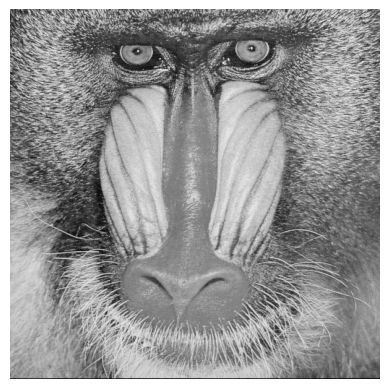

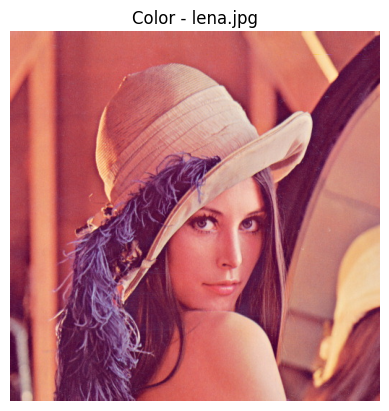

In [68]:
gray = cv2.imread("data/images/baboon.jpg", 0)
color = cv2.imread("data/images/lena.jpg")

print(gray.shape, gray.dtype)
print(color.shape, color.dtype)

plt.imshow(gray, cmap="gray"); plt.axis("off"); plt.show()
plt.title("Grayscale - baboon.jpg")

plt.imshow(cv2.cvtColor(color, cv2.COLOR_BGR2RGB))
plt.title("Color - lena.jpg")
plt.axis("off"); plt.show()

### 1.3 Apply the four morphological operations

Threshold used: 127.0


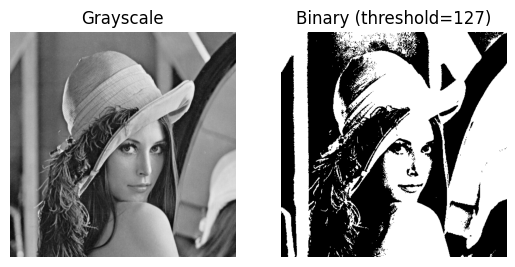

In [69]:
img_lena = cv2.imread("data/images/lena.jpg", cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img_lena, cv2.COLOR_BGR2GRAY)

ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

print("Threshold used:", ret)

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary (threshold=127)")
plt.axis("off")

plt.show()

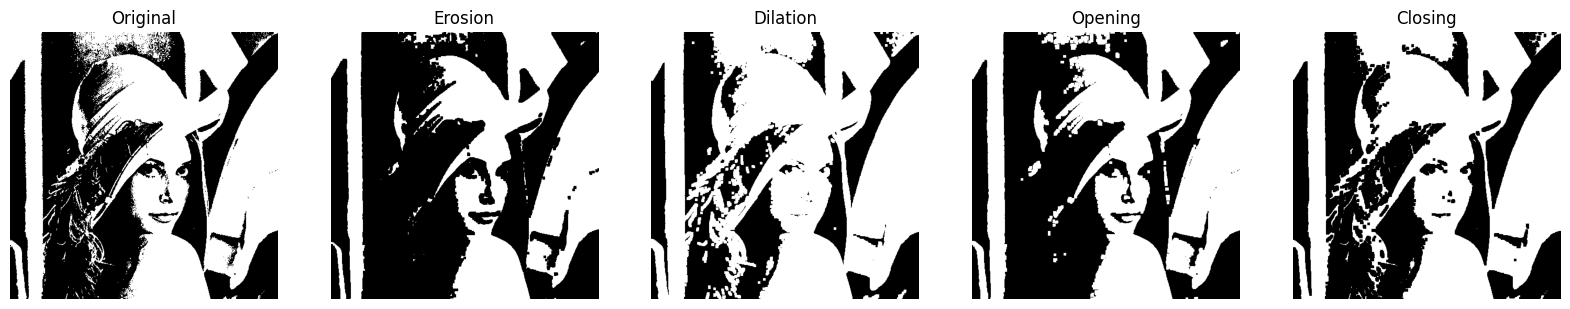

In [70]:
kernel=np.ones((5,5),np.uint8)
erosion=cv2.erode(binary,kernel)
dilation=cv2.dilate(binary,kernel)
opening=cv2.morphologyEx(binary,cv2.MORPH_OPEN,kernel)
closing=cv2.morphologyEx(binary,cv2.MORPH_CLOSE,kernel)

plt.figure(figsize=(20,4))
for i,(img,title) in enumerate(zip([binary,erosion,dilation,opening,closing],
                                   ["Original","Erosion","Dilation","Opening","Closing"]),1):
    plt.subplot(1,5,i); plt.imshow(img,cmap="gray"); plt.title(title); plt.axis("off")
plt.show()

### 1.4 — Kernel shape & size comparison

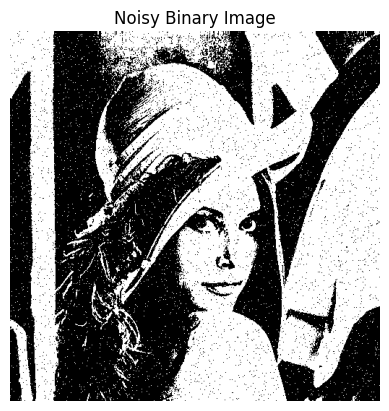

In [71]:
noisy_binary = binary.copy()

height = noisy_binary.shape[0]
width = noisy_binary.shape[1]
num_noise_pixels = int(0.02 * height * width)

for i in range(num_noise_pixels):
    row = np.random.randint(0, height)
    col = np.random.randint(0, width)
    noisy_binary[row, col] = 255

for i in range(num_noise_pixels):
    row = np.random.randint(0, height)
    col = np.random.randint(0, width)
    noisy_binary[row, col] = 0

plt.imshow(noisy_binary, cmap="gray")
plt.title("Noisy Binary Image")
plt.axis("off")
plt.show()

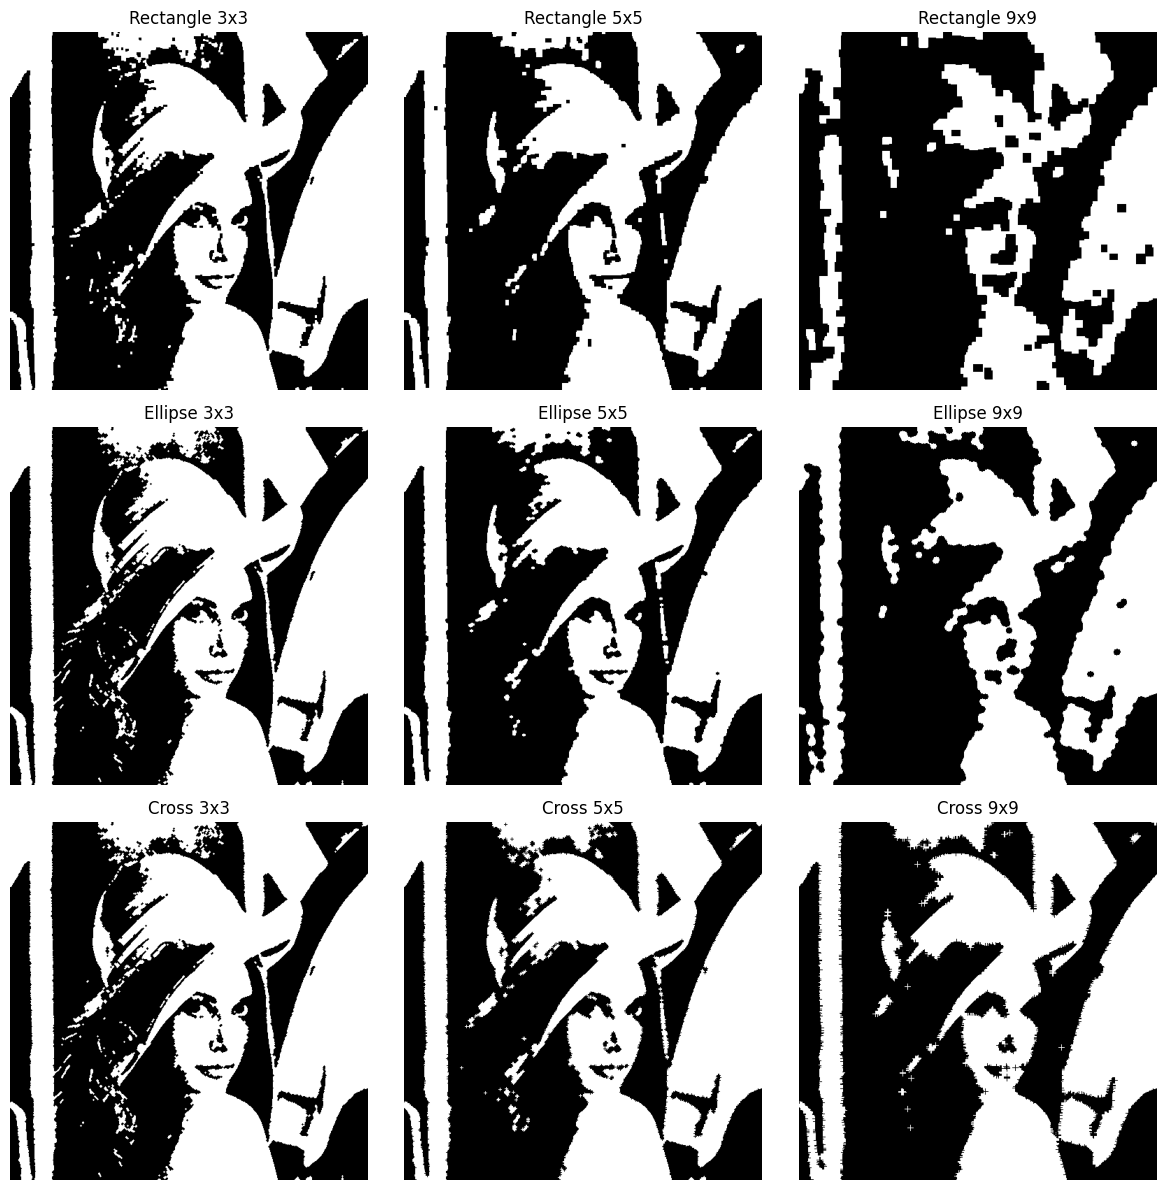

In [72]:
plt.figure(figsize=(12,12))

sizes=[3,5,9]
n=1

for shape,name in [(cv2.MORPH_RECT,"Rectangle"),
                   (cv2.MORPH_ELLIPSE,"Ellipse"),
                   (cv2.MORPH_CROSS,"Cross")]:
    for s in sizes:
        k=cv2.getStructuringElement(shape,(s,s))
        result=cv2.morphologyEx(
            cv2.morphologyEx(noisy_binary,cv2.MORPH_OPEN,k),
            cv2.MORPH_CLOSE,k
        )
        plt.subplot(3,3,n)
        plt.imshow(result,cmap="gray")
        plt.title(f"{name} {s}x{s}")
        plt.axis("off")
        n+=1

plt.tight_layout()
plt.show()

### WHY Morphology Works

- **Erosion:** Local minimum filter; shrinks white regions and removes small bright noise.
- **Dilation:** Local maximum filter; grows white regions and fills small dark gaps.
- **Opening:** Erosion → Dilation; removes small bright noise.
- **Closing:** Dilation → Erosion; fills small dark gaps and preserves object shape.

## Task 2: Bitwise Operations & Image Histograms
### 2.1 Bitwise AND / OR / XOR / NOT

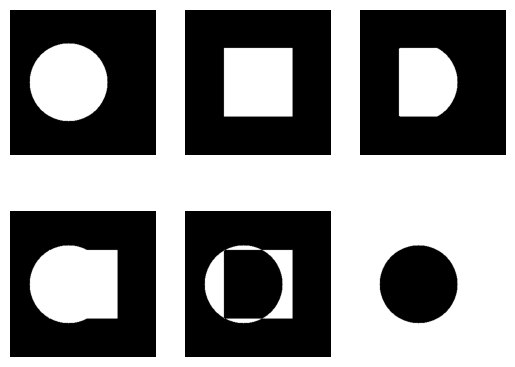

In [73]:
a=np.zeros((300,300),np.uint8)
b=np.zeros((300,300),np.uint8)

cv2.circle(a,(120,150),80,255,-1)
cv2.rectangle(b,(80,80),(220,220),255,-1)

ops=[a,b,cv2.bitwise_and(a,b),cv2.bitwise_or(a,b),
     cv2.bitwise_xor(a,b),cv2.bitwise_not(a)]
titles=["Mask 1","Mask 2","NOT","AND","OR","XOR"]


for i,x in enumerate(ops,1):
    plt.subplot(2,3,i); plt.imshow(x,cmap="gray"); plt.axis("off")

plt.show()

### 2.2 Applied use-case: masked overlay

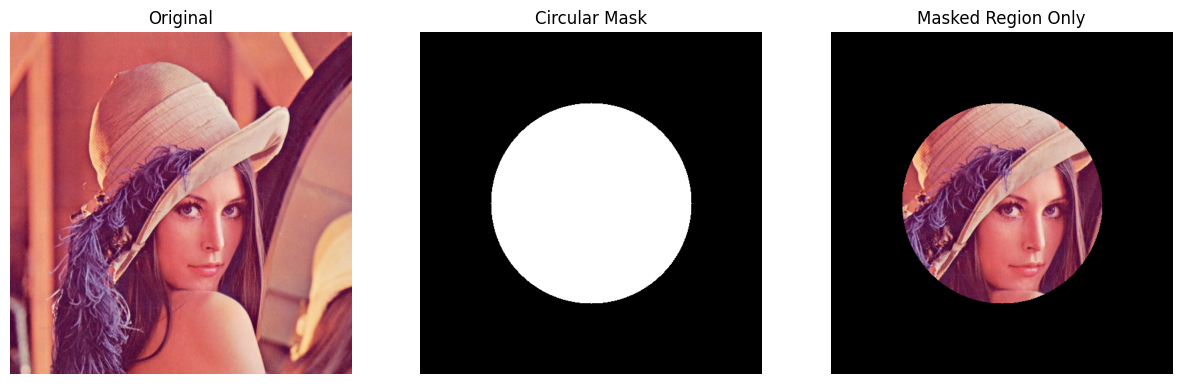

In [74]:
img=cv2.imread("data/images/lena.jpg")
rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

h,w=img.shape[:2]
mask=np.zeros((h,w),np.uint8)
cv2.circle(mask,(w//2,h//2),150,255,-1)

masked=cv2.bitwise_and(img,img,mask=mask)
masked=cv2.cvtColor(masked,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,5))
for i,(x,t) in enumerate([(rgb,"Original"),(mask,"Circular Mask"),(masked,"Masked Region Only")],1):
    plt.subplot(1,3,i); plt.imshow(x,cmap="gray"); plt.title(t); plt.axis("off")
plt.show()

### 2.3 Grayscale & per-channel colour histograms

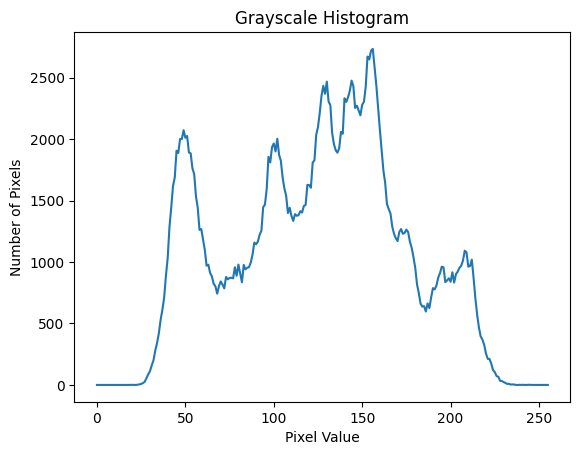

In [76]:
img=cv2.imread("data/images/lena.jpg")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
hist=cv2.calcHist([gray],[0],None,[256],[0,256])

plt.plot(hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Number of Pixels"); plt.show()

### 2.4 Brightness & contrast adjustment

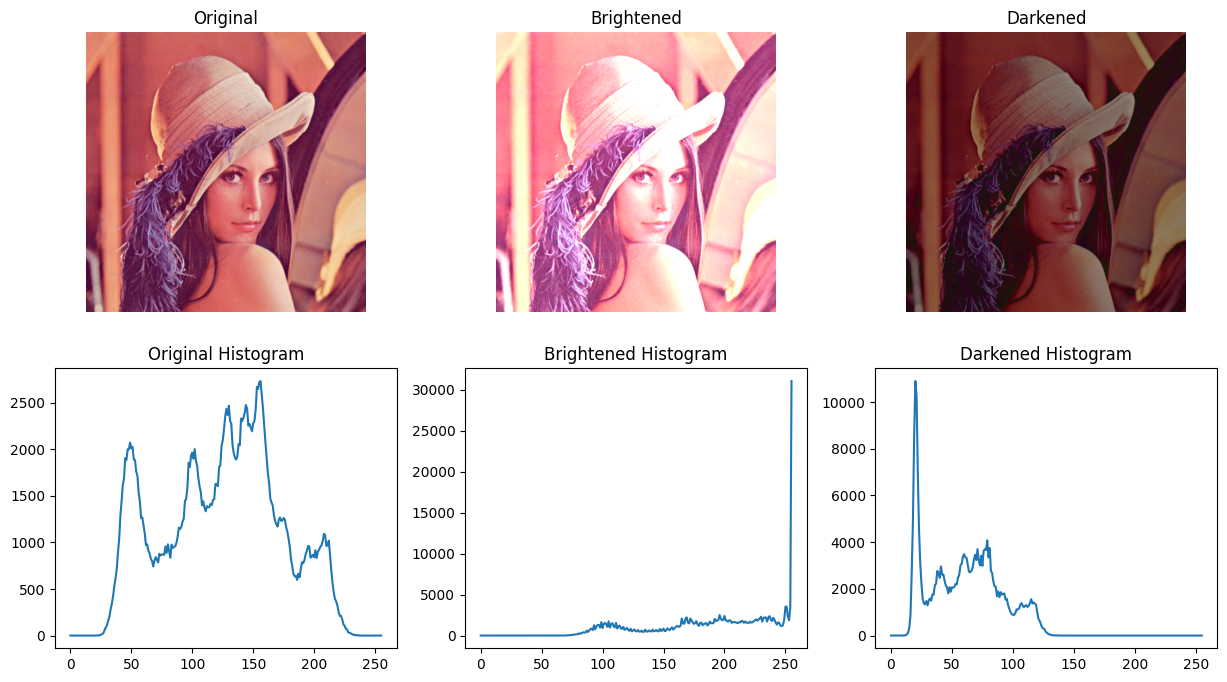

In [77]:
bright=cv2.convertScaleAbs(img_lena,alpha=1.5,beta=30)
dark=cv2.convertScaleAbs(img_lena,alpha=.7,beta=-30)

imgs=[img_lena,bright,dark]
titles=["Original","Brightened","Darkened"]

plt.figure(figsize=(15,8))
for i,(x,t) in enumerate(zip(imgs,titles),1):
    plt.subplot(2,3,i)
    plt.imshow(cv2.cvtColor(x,cv2.COLOR_BGR2RGB))
    plt.title(t); plt.axis("off")

for i,x in enumerate(imgs,4):
    h=cv2.calcHist([cv2.cvtColor(x,cv2.COLOR_BGR2GRAY)],[0],None,[256],[0,256])
    plt.subplot(2,3,i); plt.plot(h); plt.title(titles[i-4]+" Histogram")

plt.show()

### 2.5 Why Alpha/Beta and Histograms Matter

`new_pixel = alpha * pixel + beta`

- **Alpha:** Controls contrast.
- **Beta:** Controls brightness.
- **Narrow histogram:** Low contrast.
- **Pixels at 0 or 255:** Under/over-exposure and lost detail.
- **Use:** Histograms help decide if brightness/contrast adjustment is needed before detection.

## Task 3: Face Detection with YuNet (OpenCV 5.0)

### 3.1 Load the YuNet face detector

In [79]:
img_face = cv2.imread("data/images/face1.jpeg", cv2.IMREAD_COLOR)

img_height = img_face.shape[0]
img_width = img_face.shape[1]

detector = cv2.FaceDetectorYN_create(
    "data/models/face_detection_yunet_2023mar.onnx",
    "",
    (img_width, img_height),
    score_threshold=0.7
)

print("Image size used:", img_width, "x", img_height)

Image size used: 1115 x 1600


### 3.2 Detect on static images

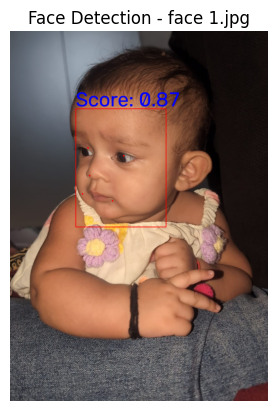

In [81]:
def detect_and_draw(image_path, detector):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    height = img.shape[0]
    width = img.shape[1]

    detector.setInputSize((width, height))
    result, faces = detector.detect(img)

    if faces is not None:
        for face in faces:
            x = int(face[0])
            y = int(face[1])
            w = int(face[2])
            h = int(face[3])
            score = face[14]

            cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)

            for i in range(5):
                landmark_x = int(face[4 + i * 2])
                landmark_y = int(face[4 + i * 2 + 1])
                cv2.circle(img, (landmark_x, landmark_y), 2, (0, 0, 255), 2)

            # Write the confidence score
            text = "Score: " + str(round(score, 2))
            cv2.putText(img, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 3, (255,0, 0), 1)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb

result1 = detect_and_draw("data/images/face1.jpeg", detector)
plt.imshow(result1)
plt.title("Face Detection - face 1.jpg")
plt.axis("off")
plt.show()

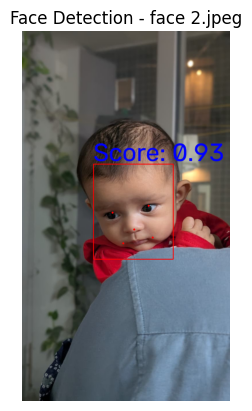

In [82]:
result2 = detect_and_draw("data/images/face2.jpg", detector)
plt.imshow(result2)
plt.title("Face Detection - face 2.jpeg")
plt.axis("off")
plt.show()

### 3.3 Real-time detection on webcam

In [85]:
import time

cap = cv2.VideoCapture(0)

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
detector.setInputSize((frame_width, frame_height))

frame_count = 0
start_time = time.time()

while True:
    ret, frame = cap.read()
    if ret == False:
        break

    result, faces = detector.detect(frame)

    if faces is not None:
        for face in faces:
            x = int(face[0])
            y = int(face[1])
            w = int(face[2])
            h = int(face[3])
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    cv2.imshow("YuNet Face Detection", frame)
    frame_count = frame_count + 1

    if cv2.waitKey(1) & 0xFF == 27:
        break

end_time = time.time()
total_time = end_time - start_time
fps = frame_count / total_time

print("Frames processed:", frame_count)
print("Total time (seconds):", total_time)
print("Average FPS:", fps)

cap.release()
cv2.destroyAllWindows()

Frames processed: 90
Total time (seconds): 3.849797487258911
Average FPS: 23.377853068339128


### 3.4 Score-threshold experiment & applied privacy use-case

In [86]:
thresholds = [0.5, 0.7, 0.9]

for t in thresholds:
    temp_detector = cv2.FaceDetectorYN_create(
        "data/models/face_detection_yunet_2023mar.onnx",
        "",
        (img_width, img_height),
        score_threshold=t
    )
    result, faces = temp_detector.detect(img_face)

    if faces is not None:
        num_faces = len(faces)
    else:
        num_faces = 0

    print("Threshold:", t, "-> Faces detected:", num_faces)

Threshold: 0.5 -> Faces detected: 1
Threshold: 0.7 -> Faces detected: 1
Threshold: 0.9 -> Faces detected: 0


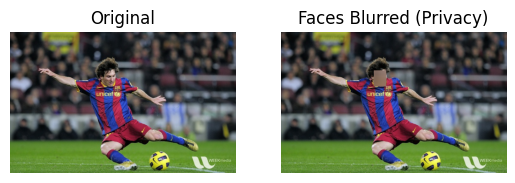

In [88]:
img_to_blur = cv2.imread("data/images/messi5.jpg", cv2.IMREAD_COLOR)
blur_height = img_to_blur.shape[0]
blur_width = img_to_blur.shape[1]

detector.setInputSize((blur_width, blur_height))
result, faces = detector.detect(img_to_blur)

img_blurred = img_to_blur.copy()

if faces is not None:
    for face in faces:
        x = int(face[0])
        y = int(face[1])
        w = int(face[2])
        h = int(face[3])

        # Extract just the face region
        face_region = img_blurred[y:y+h, x:x+w]

        # Blur only that region
        blurred_face = cv2.GaussianBlur(face_region, (51, 51), 30)

        # Put the blurred region back
        img_blurred[y:y+h, x:x+w] = blurred_face

original_rgb = cv2.cvtColor(img_to_blur, cv2.COLOR_BGR2RGB)
blurred_rgb = cv2.cvtColor(img_blurred, cv2.COLOR_BGR2RGB)

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred_rgb)
plt.title("Faces Blurred (Privacy)")
plt.axis("off")

plt.show()

### 3.5 Why YuNet

YuNet is a small and fast CNN-based face detector in OpenCV. It detects faces and provides 5 facial landmarks.

- **Good generalisation:** Works with different face angles, occlusion, and small/blurry faces.
- **Score threshold:** Low threshold → more faces but more false positives. High threshold → fewer false positives but may miss faces.
- **Real-time security:** Use around **0.5–0.7**.
- **Photo tagging:** Use around **0.9** for higher precision.

## Task 4: Object Detection with YOLO
### 4.1 Load pretrained YOLOv8 & run on static images

In [89]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")


image 1/1 d:\DL\PR3\data\images\messi5.jpg: 416x640 8 persons, 1 sports ball, 14.4ms
Speed: 245.8ms preprocess, 14.4ms inference, 22.9ms postprocess per image at shape (1, 3, 416, 640)


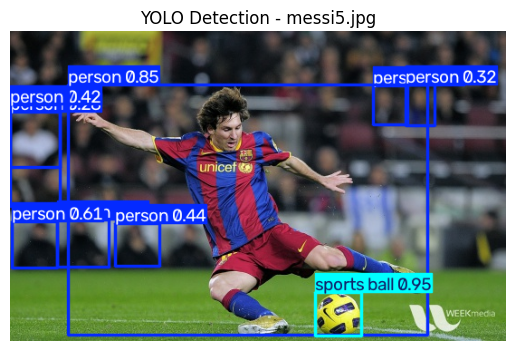

In [90]:
results = model("data/images/messi5.jpg")

annotated_img = results[0].plot()

annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.imshow(annotated_img_rgb)
plt.title("YOLO Detection - messi5.jpg")
plt.axis("off")
plt.show()


image 1/1 d:\DL\PR3\data\images\smarties.png: 576x640 5 sports balls, 1 apple, 2 oranges, 130.8ms
Speed: 7.3ms preprocess, 130.8ms inference, 6.9ms postprocess per image at shape (1, 3, 576, 640)


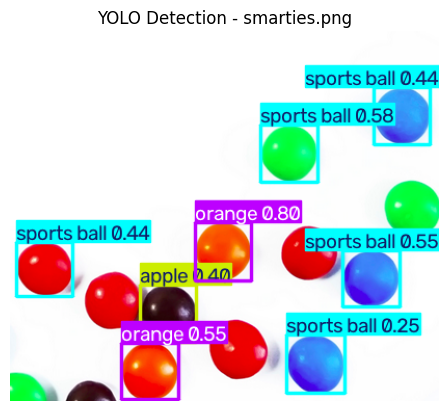

In [94]:
r=model("data/images/smarties.png")[0].plot()

plt.imshow(cv2.cvtColor(r,cv2.COLOR_BGR2RGB))
plt.title("YOLO Detection - smarties.png"); plt.axis("off"); plt.show()


image 1/1 d:\DL\PR3\data\images\home.jpg: 480x640 7 kites, 138.7ms
Speed: 1075.2ms preprocess, 138.7ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)


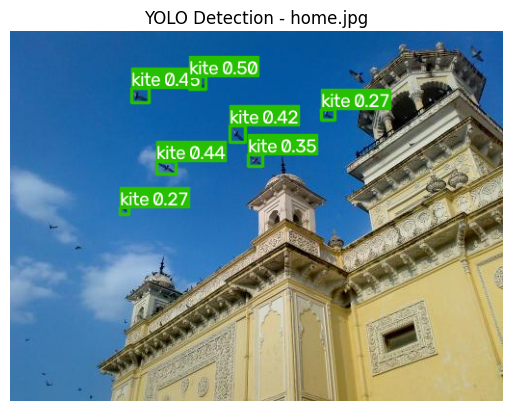

In [91]:
r=model("data/images/home.jpg")[0].plot()

plt.imshow(cv2.cvtColor(r,cv2.COLOR_BGR2RGB))
plt.title("YOLO Detection - home.jpg"); plt.axis("off"); plt.show()

### 4.2 YOLO on webcam

In [96]:
import time

cap = cv2.VideoCapture(0)

frame_count = 0
start_time = time.time()

while True:
    ret, frame = cap.read()
    if ret == False:
        break

    results = model(frame, verbose=False)
    annotated_frame = results[0].plot()

    cv2.imshow("YOLO Detection", annotated_frame)
    frame_count = frame_count + 1

    if cv2.waitKey(1) & 0xFF == 27:
        break

end_time = time.time()
total_time = end_time - start_time
fps = frame_count / total_time

print("Frames processed:", frame_count)
print("Total time (seconds):", total_time)
print("Average FPS:", fps)

cap.release()
cv2.destroyAllWindows()

Frames processed: 25
Total time (seconds): 1.4849677085876465
Average FPS: 16.835382921408783


### 4.3 Confidence & IoU threshold tuning

image 1/1 d:\DL\PR3\data\images\messi5.jpg: 416x640 27 persons, 1 sports ball, 46.4ms
Speed: 4.7ms preprocess, 46.4ms inference, 2.3ms postprocess per image at shape (1, 3, 416, 640)

image 1/1 d:\DL\PR3\data\images\messi5.jpg: 416x640 17 persons, 1 sports ball, 55.0ms
Speed: 6.2ms preprocess, 55.0ms inference, 3.7ms postprocess per image at shape (1, 3, 416, 640)


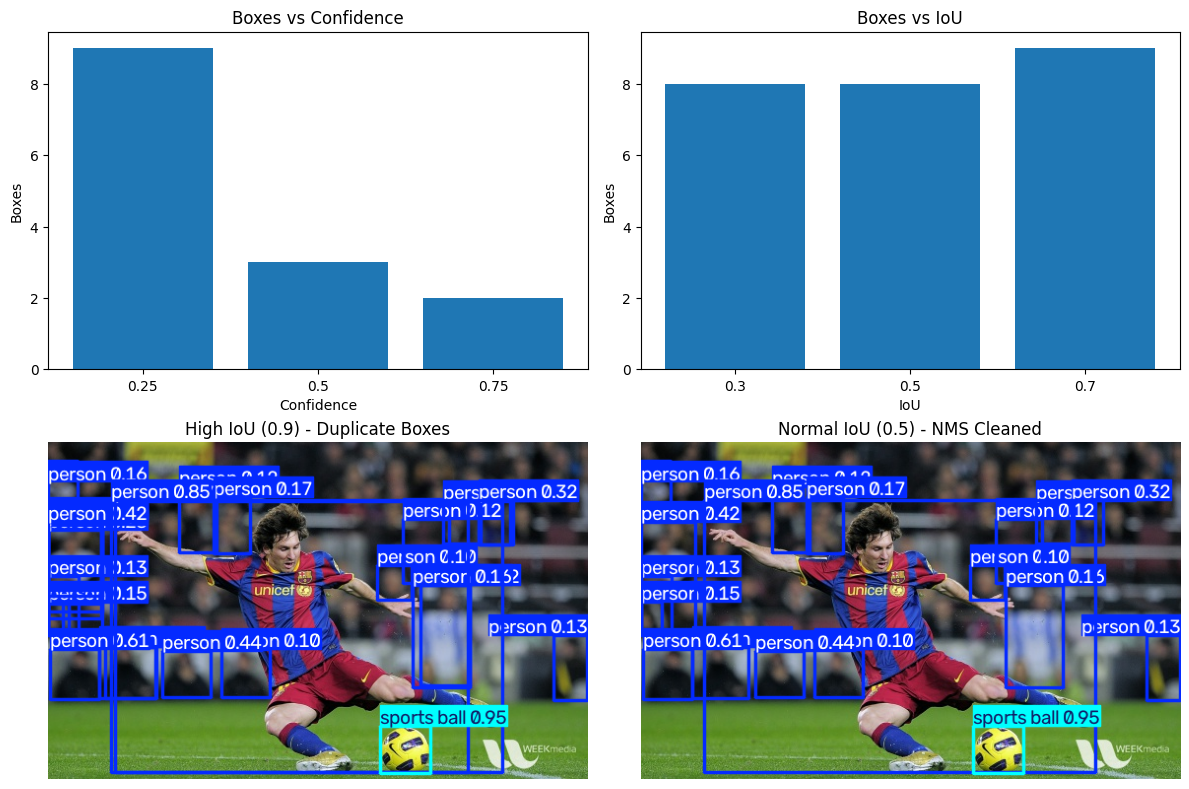

In [102]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.bar([str(x) for x in conf],c_counts)
plt.title("Boxes vs Confidence")
plt.xlabel("Confidence"); plt.ylabel("Boxes")

plt.subplot(2,2,2)
plt.bar([str(x) for x in iou],i_counts)
plt.title("Boxes vs IoU")
plt.xlabel("IoU"); plt.ylabel("Boxes")

low=model("data/images/messi5.jpg",iou=.9,conf=.1)[0].plot()
normal=model("data/images/messi5.jpg",iou=.5,conf=.1)[0].plot()

plt.subplot(2,2,3)
plt.imshow(cv2.cvtColor(low,cv2.COLOR_BGR2RGB))
plt.title("High IoU (0.9) - Duplicate Boxes"); plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(normal,cv2.COLOR_BGR2RGB))
plt.title("Normal IoU (0.5) - NMS Cleaned"); plt.axis("off")

plt.tight_layout()
plt.show()

### 4.4 Per-class detection summary

In [103]:
images=["data/images/messi5.jpg","data/images/home.jpg","data/images/smarties.png"]
counts={}

for path in images:
    r=model(path)[0]
    for box in r.boxes:
        name=r.names[int(box.cls[0])]
        counts[name]=counts.get(name,0)+1

print(counts)


image 1/1 d:\DL\PR3\data\images\messi5.jpg: 416x640 8 persons, 1 sports ball, 46.8ms
Speed: 4.1ms preprocess, 46.8ms inference, 4.6ms postprocess per image at shape (1, 3, 416, 640)

image 1/1 d:\DL\PR3\data\images\home.jpg: 480x640 7 kites, 54.4ms
Speed: 4.8ms preprocess, 54.4ms inference, 2.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 d:\DL\PR3\data\images\smarties.png: 576x640 5 sports balls, 1 apple, 2 oranges, 65.1ms
Speed: 5.7ms preprocess, 65.1ms inference, 3.8ms postprocess per image at shape (1, 3, 576, 640)
{'sports ball': 6, 'person': 8, 'kite': 7, 'orange': 2, 'apple': 1}


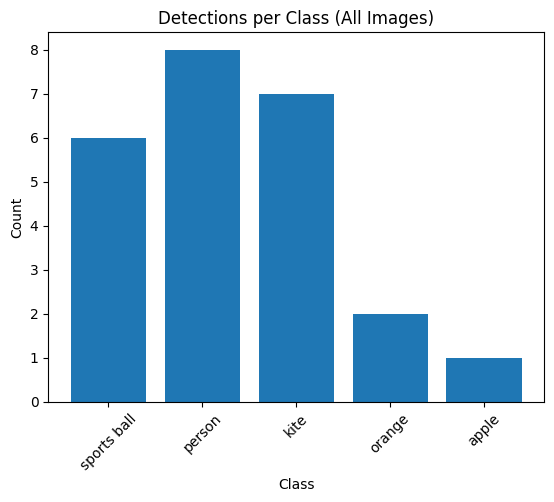

In [106]:
plt.bar(counts.keys(),counts.values())
plt.title("Detections per Class (All Images)")
plt.xlabel("Class"); plt.ylabel("Count")
plt.xticks(rotation=45); plt.show()

### 4.5 Why YOLO Generalises

YOLO is a fast, single-stage detector that predicts object boxes and classes in one pass. NMS removes duplicate boxes.

- **YOLOv8n:** Smallest and fastest; good for real-time use.
- **YOLOv8s/m/l/x:** Larger and more accurate but slower.
- **80 COCO classes:** One pretrained model can detect all classes using shared learned features.

YOLO is useful because it provides a good balance of **speed, accuracy, and generalisation**.

## Task 5: Integrated Pipeline & Final Comparison

### 5.1 Build the unified pipeline

In [ ]:
cap = cv2.VideoCapture(0)

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
detector.setInputSize((frame_width, frame_height))

while True:
    ret, frame = cap.read()
    if ret == False:
        break
    
    result, faces = detector.detect(frame)
    if faces is not None:
        for face in faces:
            x = int(face[0])
            y = int(face[1])
            w = int(face[2])
            h = int(face[3])
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    results = model(frame, verbose=False)
    boxes = results[0].boxes
    names = results[0].names

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0]
        x1 = int(x1)
        y1 = int(y1)
        x2 = int(x2)
        y2 = int(y2)

        class_id = int(box.cls[0])
        class_name = names[class_id]

        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(frame, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    cv2.imshow("Integrated Pipeline - Face (Green) + YOLO (Red)", frame)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

### 5.2 Morphological pre-cleaning


0: 480x640 2 birds, 52.8ms
Speed: 5.1ms preprocess, 52.8ms inference, 3.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 bird, 3 kites, 52.8ms
Speed: 4.5ms preprocess, 52.8ms inference, 2.9ms postprocess per image at shape (1, 3, 480, 640)
Boxes detected (noisy): 2
Boxes detected (cleaned): 4


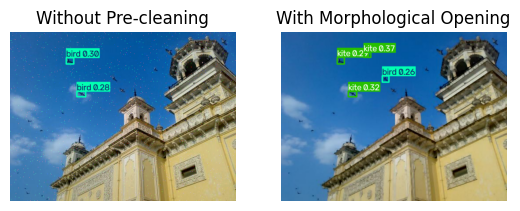

In [ ]:
img_noisy_test = cv2.imread("data/images/home.jpg", cv2.IMREAD_COLOR)

noisy_test = img_noisy_test.copy()
height = noisy_test.shape[0]
width = noisy_test.shape[1]
num_noise_pixels = int(0.01 * height * width)

for i in range(num_noise_pixels):
    row = np.random.randint(0, height)
    col = np.random.randint(0, width)
    channel = np.random.randint(0, 3)
    noisy_test[row, col, channel] = 255

kernel_small = np.ones((3, 3), np.uint8)
cleaned_test = cv2.morphologyEx(noisy_test, cv2.MORPH_OPEN, kernel_small)

results_noisy = model(noisy_test)
results_cleaned = model(cleaned_test)

annotated_noisy = results_noisy[0].plot()
annotated_cleaned = results_cleaned[0].plot()

annotated_noisy_rgb = cv2.cvtColor(annotated_noisy, cv2.COLOR_BGR2RGB)
annotated_cleaned_rgb = cv2.cvtColor(annotated_cleaned, cv2.COLOR_BGR2RGB)

print("Boxes detected (noisy):", len(results_noisy[0].boxes))
print("Boxes detected (cleaned):", len(results_cleaned[0].boxes))

plt.subplot(1, 2, 1)
plt.imshow(annotated_noisy_rgb)
plt.title("Without Pre-cleaning")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(annotated_cleaned_rgb)
plt.title("With Morphological Opening")
plt.axis("off")

plt.show()

### 5.3 FPS benchmarking

In [110]:
import time

def benchmark_face_only(num_frames):
    cap = cv2.VideoCapture(0)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    detector.setInputSize((frame_width, frame_height))

    start_time = time.time()
    count = 0
    while count < num_frames:
        ret, frame = cap.read()
        if ret == False:
            break
        result, faces = detector.detect(frame)
        count = count + 1
    end_time = time.time()

    cap.release()
    return count / (end_time - start_time)


def benchmark_yolo_only(num_frames):
    cap = cv2.VideoCapture(0)
    start_time = time.time()
    count = 0
    while count < num_frames:
        ret, frame = cap.read()
        if ret == False:
            break
        results = model(frame, verbose=False)
        count = count + 1
    end_time = time.time()

    cap.release()
    return count / (end_time - start_time)


def benchmark_combined(num_frames):
    cap = cv2.VideoCapture(0)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    detector.setInputSize((frame_width, frame_height))

    start_time = time.time()
    count = 0
    while count < num_frames:
        ret, frame = cap.read()
        if ret == False:
            break
        result, faces = detector.detect(frame)
        results = model(frame, verbose=False)
        count = count + 1
    end_time = time.time()

    cap.release()
    return count / (end_time - start_time)


fps_face = benchmark_face_only(100)
fps_yolo = benchmark_yolo_only(100)
fps_combined = benchmark_combined(100)

print("Face detection FPS:", fps_face)
print("YOLO FPS:", fps_yolo)
print("Combined FPS:", fps_combined)

Face detection FPS: 24.166196994505327
YOLO FPS: 25.850249155783057
Combined FPS: 17.509940470934833


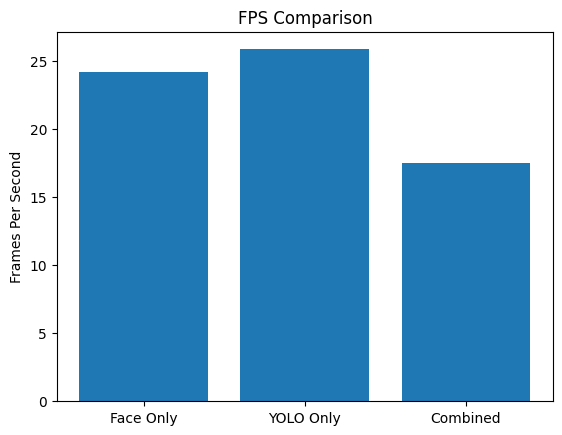

In [111]:
labels = ["Face Only", "YOLO Only", "Combined"]
fps_values = [fps_face, fps_yolo, fps_combined]

plt.bar(labels, fps_values)
plt.title("FPS Comparison")
plt.ylabel("Frames Per Second")
plt.show()

### 5.4 Final Results Comparison Table

| Technique | Type | Detects | Lighting | FPS | Best Use |
|---|---|---|---|---|---|
| Morphology | Classical | Noise/shape | Low | >100 | Mask cleaning |
| Bitwise & Histogram | Classical | Mask/brightness | Low-Medium | >100 | ROI/diagnostics |
| YuNet | Deep Learning | Faces + landmarks | High | Medium | Face detection |
| YOLOv8n | Deep Learning | 80 objects | High | Medium | Object detection |

### 5.5 Reflection

YuNet with a moderate threshold (~0.7) and YOLOv8n provides a good balance between accuracy and speed for real-time detection.

- **Edge device:** Use YOLOv8n and a slightly higher YuNet threshold to reduce false positives.
- **Cloud/server:** Use YOLOv8s or YOLOv8m for better accuracy when more computing power is available.